# Faraday

This tutorial explains how Faraday works and how to use Faraday to train a generative model and generate synthetic smart meter data.

---

Faraday is a Conditional Variational Auto-Encoder (VAE)-based model. Unlike traditional VAEs where seeds are drawn from a normal distribution and decoded, Faraday works by:
1. First train a VAE using the following loss functions: a. MMD instead of KL-divergence b. Quantile losses and c. Mean squared error
2. Encode real samples to the latent space using the encoder, and fit a Gaussian Mixture Model (GMM) over the latent space.
3. During inference, draw samples from the GMM and decode with the decoder.

For more information on Faraday's architecture, refer to the [Faraday paper](https://arxiv.org/abs/2404.04314).

In [2]:
%load_ext autoreload
%autoreload 2

In [7]:
import os

import sys
import torch
import logging
from opensynth.models.faraday.model import FaradayModel

logger = logging.getLogger(__name__)

# 💿 Loading GoiEnerData

In [2]:
from pathlib import Path
from opensynth.data_modules.goiener_data_module import GoiEnerDataModule
import pytorch_lightning as pl

import matplotlib.pyplot as plt

data_path = Path("../../data/processed/goiener/historical/train/data.csv")
stats_path = Path("../../data/processed/goiener/historical/train/mean_std.csv")
outlier_path = Path("../../data/processed/goiener/historical/train/outliers.csv")

In [3]:
n_daily_readings = 24 # 24 for hourly resolution, 48 for half-hourly resolution

batch_size = 50000
n_samples = 250000
batch_size_with_outliers = 1000
n_samples_with_outliers = 50000
batch_size_gmm = 25000
n_samples_gmm = 200000

In [13]:
dm = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=batch_size, n_samples=n_samples)
dm.setup()

In [14]:
dm_with_outliers = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=batch_size_with_outliers, n_samples=n_samples_with_outliers, outlier_path=outlier_path)
dm_with_outliers.setup()

# 🤖 VAE Module

In [6]:
from opensynth.models.faraday.vae_model import FaradayVAE
# Option to pass in your own encoder architecture in the future
model = FaradayVAE(class_dim=3, latent_dim=32, input_dim=n_daily_readings, learning_rate=0.001, mse_weight=3)

/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Batch size 500 is when MPS becomes faster than CPU..
# But sometimes large batch size hurts convergence..
# Suggest training on CPU with small batch size
# And potentially experiment with best hyperparameters on large batch size before using 'mps'

trainer = pl.Trainer(max_epochs=500, accelerator="auto")
trainer.fit(model, dm_with_outliers)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name           | Type                    | Params | Mode 
-------------------------------------------------------------------
0 | encoder        | Encoder           

Epoch 499: 100%|██████████| 50/50 [00:02<00:00, 24.05it/s, v_num=9, total_loss=0.304, mmd_loss=0.000742, mse_loss=0.0576, quantile_loss=0.246]

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 50/50 [00:02<00:00, 23.70it/s, v_num=9, total_loss=0.304, mmd_loss=0.000742, mse_loss=0.0576, quantile_loss=0.246]


In [8]:
torch.save(model, "vae_model.pt")

# 🕸️ GMM Module

In [8]:
# torch.save(model, "faraday_model.pt")
model = torch.load("vae_model.pt", weights_only=False)

Need to update model s.t. `feature_list` is saved if want to load model from checkpoint. For now, use trained VAE. 

In [37]:
# model = FaradayVAE.load_from_checkpoint("lightning_logs/version_0/checkpoints/epoch=249-step=25000.ckpt", map_location=torch.device('cpu'))

# faraday_model_1500 = FaradayModel(vae_module=model, n_components=1500, max_iter=100, tol=1e-2)
# faraday_model_150 = FaradayModel(vae_module=model, n_components=150, max_iter=100, tol=1e-2)
# faraday_model_50 = FaradayModel(vae_module=model, n_components=50, max_iter=100, tol=1e-2)
# faraday_model_10 = FaradayModel(vae_module=model, n_components=10, max_iter=100, tol=1e-2)
# faraday_model_1 = FaradayModel(vae_module=model, n_components=1, max_iter=100, tol=1e-2)


In [19]:
faraday_model_150 = FaradayModel(
    vae_module=model, n_components=150, tol=1e-3, max_epochs=100, covariance_reg=1e-2,
)

faraday_model_50 = FaradayModel(
    vae_module=model, n_components=50, tol=1e-3, max_epochs=100, covariance_reg=1e-2,
)

faraday_model_10 = FaradayModel(
    vae_module=model, n_components=10, tol=1e-3, max_epochs=100, covariance_reg=1e-2,
)

In [23]:
gmm_data_module = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=batch_size_gmm, n_samples=n_samples_gmm, outlier_path=outlier_path)
gmm_data_module.setup()

In [22]:
# faraday_model_10.train_gmm(dm=gmm_data_module)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable Tenso

Initial prec chol: 0.2498389631509781.                 Initial mean: 20.22768783569336
Epoch 4: 100%|██████████| 8/8 [00:02<00:00,  2.92it/s, v_num=14]


In [23]:
# faraday_model_50.train_gmm(dm=gmm_data_module)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name                      | Type                        | Params | Mode 
----------------------------------------------------------------------------------
0 | gmm_module                | GaussianMixtureModel        | 0      | train
1 | vae_module                | FaradayVAE                  | 381 K  | train
2 | weight

Initial prec chol: 0.41112762689590454.                 Initial mean: 22.66584014892578
Epoch 3: 100%|██████████| 8/8 [00:04<00:00,  1.99it/s, v_num=15]


In [24]:
# faraday_model_150.train_gmm(dm=gmm_data_module)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name                      | Type                        | Params | Mode 
----------------------------------------------------------------------------------
0 | gmm_module                | GaussianMixtureModel        | 0      | train
1 | vae_module                | FaradayVAE                  | 381 K  | train
2 | weight

Initial prec chol: 0.5635298490524292.                 Initial mean: 24.20175552368164
Epoch 2: 100%|██████████| 8/8 [00:05<00:00,  1.46it/s, v_num=16]


In [27]:
# Check number of components with zero means

ligthning_sum_components = faraday_model_10.gmm_module.means.sum(axis=1)
faraday_model_10_zero_means = len(ligthning_sum_components[ligthning_sum_components==0])

ligthning_sum_components = faraday_model_50.gmm_module.means.sum(axis=1)
faraday_model_50_zero_means = len(ligthning_sum_components[ligthning_sum_components==0])

ligthning_sum_components = faraday_model_150.gmm_module.means.sum(axis=1)
faraday_model_150_zero_means = len(ligthning_sum_components[ligthning_sum_components==0])

faraday_model_10_zero_means, faraday_model_50_zero_means, faraday_model_150_zero_means

(2, 11, 65)

In [25]:
# torch.save(faraday_model_150, "faraday_model_150.pt")
# torch.save(faraday_model_50, "faraday_model_50.pt")
# torch.save(faraday_model_10, "faraday_model_10.pt")

# 📈 Comparing Results

### 0. Generating Samples

In [27]:
import pandas as pd

def generate_synthetic_samples(model, n_samples, dm):
    gmm_samples = model.sample_gmm(n_samples)
    gmm_samples_reconstructed = dm.reconstruct_kwh(gmm_samples['kwh'])
    gmm_samples_reconstructed = torch.clip(gmm_samples_reconstructed, min=0)
    return gmm_samples_reconstructed

# def generate_synthetic_samples(model, n_samples, dm):
#     samples = model.sample_gmm(n_samples)
#
#     kwh = dm.reconstruct_kwh(samples["kwh"])
#     kwh = torch.clip(kwh, min=0)
#
#     return {
#         "kwh": kwh,
#         "features": samples["features"],
#     }

def synthetic_samples_to_csv(model, n_samples, dm, out_csv: str):
    samples = model.sample_gmm(n_samples)

    # Reconstruct kWh and clip negatives
    kwh = dm.reconstruct_kwh(samples["kwh"])
    kwh = torch.clip(kwh, min=0).detach().cpu().numpy()

    # Features dict[str, Tensor] -> flat columns
    feature_dict = {}
    for name, tensor in samples["features"].items():
        feature_dict[name] = tensor.detach().cpu().numpy().reshape(-1)

    # kWh columns
    kwh_cols = [f"kwh_{i}" for i in range(kwh.shape[1])]
    df_kwh = pd.DataFrame(kwh, columns=kwh_cols)

    # Feature columns
    df_feat = pd.DataFrame(feature_dict)

    # Combine
    df_out = pd.concat([df_feat, df_kwh], axis=1)

    # Save
    df_out.to_csv(out_csv, index=True)
    return df_out

import json
from pathlib import Path

import pandas as pd
import torch


def synthetic_samples_to_csv(
    model,
    n_samples: int,
    dm,
    out_csv: str,
    encoder_json_path: str = "goiener_feature_encoders.json",
):
    """
    Generate synthetic GoiEner samples and save to wide CSV with decoded categorical features.
    Output columns:
      [month, dayofweek, cnae, postal_code, p1_kw, tarriff, kwh_0, ..., kwh_{T-1}]
    """

    # 1) Sample synthetic data from Faraday (returns {"kwh": Tensor, "features": dict})
    samples = model.sample_gmm(n_samples)

    # 2) Reconstruct kWh and clip negatives
    kwh = dm.reconstruct_kwh(samples["kwh"])
    kwh = torch.clip(kwh, min=0).detach().cpu().numpy()

    # 3) Build features dataframe in stable order
    feature_order = ["month", "dayofweek", "postal_code"]
    feature_data = {}
    for col in feature_order:
        if col not in samples["features"]:
            raise KeyError(f"Expected feature '{col}' in sampled features, got {list(samples['features'].keys())}")
        feature_data[col] = samples["features"][col].detach().cpu().numpy().reshape(-1)

    df_feat = pd.DataFrame(feature_data)

    # 4) Decode categorical features using the provided encoder JSON
    enc_path = Path(encoder_json_path)
    if not enc_path.exists():
        raise FileNotFoundError(f"Encoder file not found: {encoder_json_path}")

    with open(enc_path, "r") as f:
        encoders = json.load(f)

    # Decode only columns that are categorical_int_encoded and present in df
    for col, spec in encoders.items():
        if col not in df_feat.columns:
            continue
        if spec.get("type") != "categorical_int_encoded":
            continue

        categories = spec.get("categories", [])
        code_to_cat = {i: cat for i, cat in enumerate(categories)}

        # sampled values may be float-like due to tensor conversions -> round safely
        codes = pd.to_numeric(df_feat[col], errors="coerce").round().astype("Int64")
        decoded = codes.map(code_to_cat).fillna("<UNK>")
        df_feat[col] = decoded

    # Optional: convert month/dayofweek to ints cleanly
    for col in ["month", "dayofweek"]:
        if col in df_feat.columns:
            df_feat[col] = pd.to_numeric(df_feat[col], errors="coerce").round().astype("Int64")

    # 5) Build kWh wide dataframe
    kwh_cols = [f"kwh_{i}" for i in range(kwh.shape[1])]
    df_kwh = pd.DataFrame(kwh, columns=kwh_cols)

    # 6) Combine and save
    df_out = pd.concat([df_feat, df_kwh], axis=1)
    df_out.to_csv(out_csv, index=True)

    return df_out

In [41]:
N_SAMPLES = 10
df_syn = synthetic_samples_to_csv(
    model=faraday_model_150,
    n_samples=N_SAMPLES,
    dm=gmm_data_module,
    out_csv=f"synthetic_faraday_{N_SAMPLES}.csv",
    encoder_json_path="../../data/goiener_feature_encoders.json",  # path to the file you pasted
)

In [20]:
fm = torch.load("faraday_model_150.pt", weights_only=False)

faraday_model_150 = FaradayModel(
    vae_module=fm.vae_module,
    n_components=fm.n_components,
    tol=fm.tol,
    covariance_reg=fm.covariance_reg,
    sample_weights_column=fm.sample_weights_column,
)

faraday_model_150.gmm_module = fm.gmm_module
faraday_model_150.feature_range = fm.feature_range

fm = torch.load("faraday_model_50.pt", weights_only=False)

faraday_model_50 = FaradayModel(
    vae_module=fm.vae_module,
    n_components=fm.n_components,
    tol=fm.tol,
    covariance_reg=fm.covariance_reg,
    sample_weights_column=fm.sample_weights_column,
)

faraday_model_50.gmm_module = fm.gmm_module
faraday_model_50.feature_range = fm.feature_range

fm = torch.load("faraday_model_10.pt", weights_only=False)

faraday_model_10 = FaradayModel(
    vae_module=fm.vae_module,
    n_components=fm.n_components,
    tol=fm.tol,
    covariance_reg=fm.covariance_reg,
    sample_weights_column=fm.sample_weights_column,
)

faraday_model_10.gmm_module = fm.gmm_module
faraday_model_10.feature_range = fm.feature_range

In [30]:
gmm_150 = generate_synthetic_samples(faraday_model_150, 20000, dm)
gmm_50 = generate_synthetic_samples(faraday_model_50, 20000, dm)
gmm_10 = generate_synthetic_samples(faraday_model_10, 20000, dm)

In [31]:
real_kwh = dm.reconstruct_kwh(next(iter(gmm_data_module.train_dataloader()))['kwh'])
real_kwh = torch.clip(real_kwh, min=0) # Clip min 0 to get read of negative values

### 1. Comparing mean, 95th quantile, median profiles

In [32]:
def plot_stats(real_kwh, gmm_reconstruct):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 3), sharey=True, gridspec_kw={'wspace': 0.05})

    ax1.plot(real_kwh.mean(dim=0).detach().numpy(), label="real kwh")
    ax1.plot(gmm_reconstruct.mean(dim=0).detach().numpy(), label="gmm kwh")
    ax1.set_title("Mean kWh per half hour")
    ax1.set_xlabel("Settlement Periods")
    ax1.legend()

    ax2.plot(real_kwh.quantile(0.95, dim=0).detach().numpy(), label="real kwh")
    ax2.plot(gmm_reconstruct.quantile(0.95, dim=0).detach().numpy(), label="gmm kwh")
    ax2.set_title("95th Quantile kWh per half hour")
    ax2.set_xlabel("Settlement Periods")
    ax2.legend()

    ax3.plot(real_kwh.quantile(0.5, dim=0).detach().numpy(), label="real kwh")
    ax3.set_title("Median kWh per half hour")
    ax3.set_xlabel("Settlement Periods")
    ax3.plot(gmm_reconstruct.quantile(0.5, dim=0).detach().numpy(), label="gmm kwh")
    ax3.legend()

    fig.text(0.1, 0.5, 'kWh', va='center', rotation='vertical')

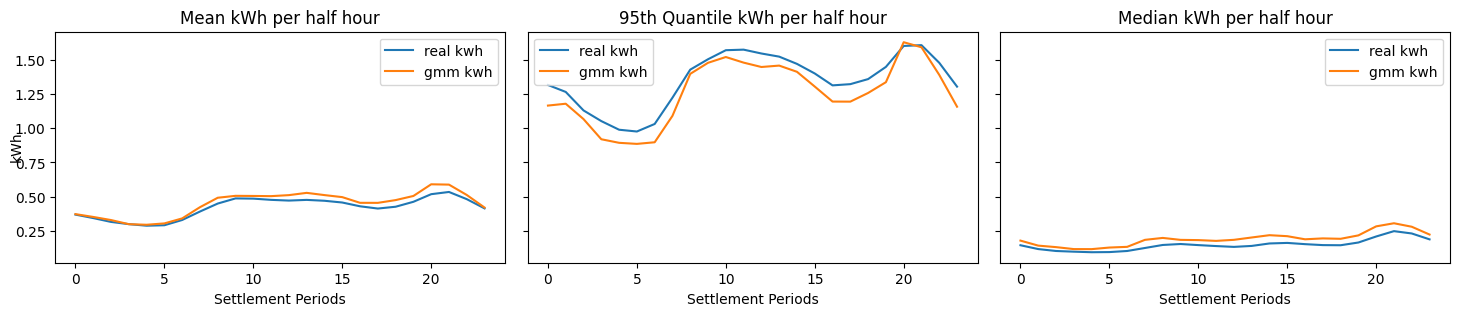

In [33]:
plot_stats(real_kwh, gmm_150)

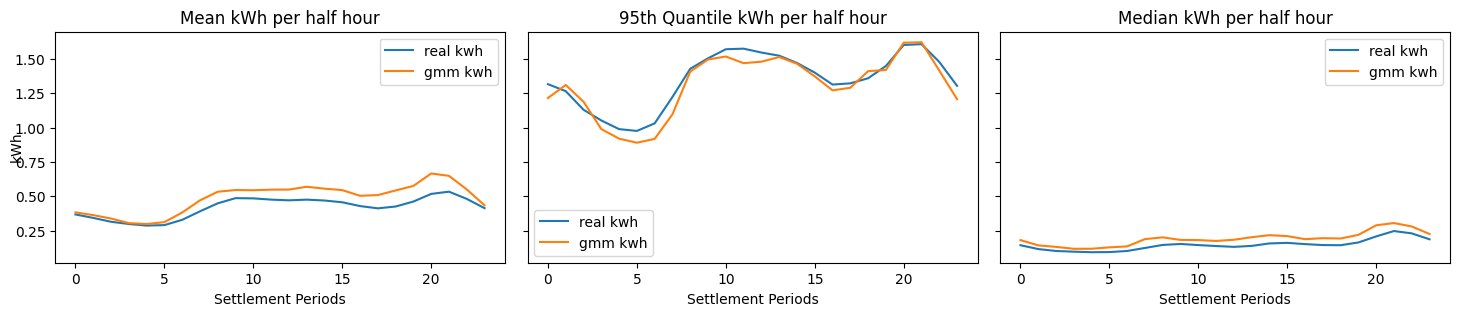

In [34]:
plot_stats(real_kwh, gmm_50)

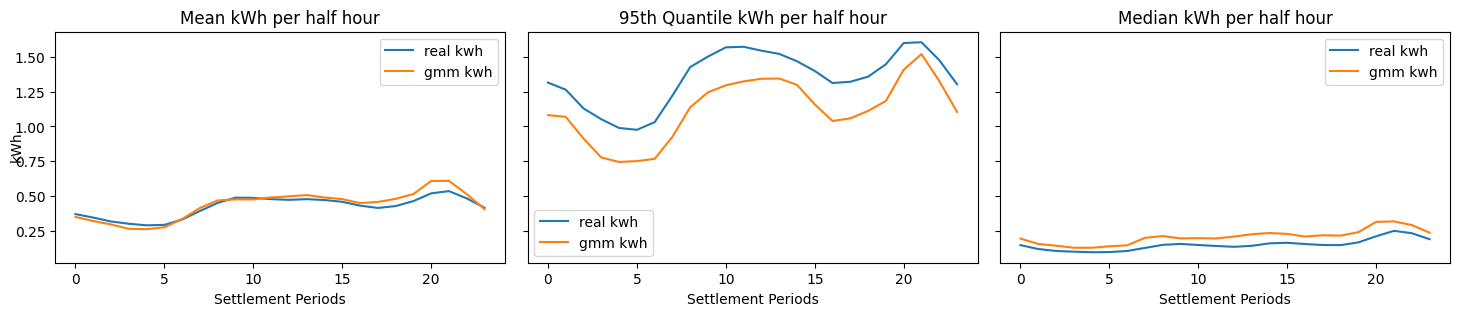

In [35]:
plot_stats(real_kwh, gmm_10)

### 2. PCA and TSNE Distribution Plots

In [36]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np


def train_pca_and_tsne(real_kwh, gmm_reconstruct):
    pca = PCA(n_components=2)
    tsne = TSNE(n_components=2)

    pca.fit(real_kwh.detach().numpy())
    pca_real = pca.transform(real_kwh.detach().numpy())
    pca_gmm = pca.transform(gmm_reconstruct.detach().numpy())

    tsne_input = np.concatenate([real_kwh.detach().numpy(), gmm_reconstruct.detach().numpy()])
    tsne_results = tsne.fit_transform(tsne_input)
    tsne_real = tsne_results[:len(real_kwh)]
    tsne_gmm = tsne_results[len(real_kwh):]

    return pca_real, pca_gmm, tsne_real, tsne_gmm


def plot_pca_tsne(pca_real, pca_gmm, tsne_real, tsne_gmm):
    fig, (ax_pca, ax_tsne) = plt.subplots(1, 2, figsize=(12, 4))

    ax_pca.scatter(pca_real[:, 0], pca_real[:, 1], label="real kwh", s=0.3, alpha=0.5)
    ax_pca.scatter(pca_gmm[:, 0], pca_gmm[:, 1], label="gmm kwh", s=0.3, alpha=0.5)
    ax_pca.set_title("PCA")
    ax_pca.set_xlabel("PCA 1")
    ax_pca.set_ylabel("PCA 2")
    ax_pca.legend()

    ax_tsne.scatter(tsne_real[:, 0], tsne_real[:, 1], label="real kwh", s=0.3, alpha=0.5)
    ax_tsne.scatter(tsne_gmm[:, 0], tsne_gmm[:, 1], label="gmm kwh", s=0.3, alpha=0.5)
    ax_tsne.set_title("TSNE")
    ax_tsne.set_xlabel("TSNE 1")
    ax_tsne.set_ylabel("TSNE 2")
    ax_tsne.legend()
    return fig


Text(0.5, 1.0, 'GMM with 150 clusters')

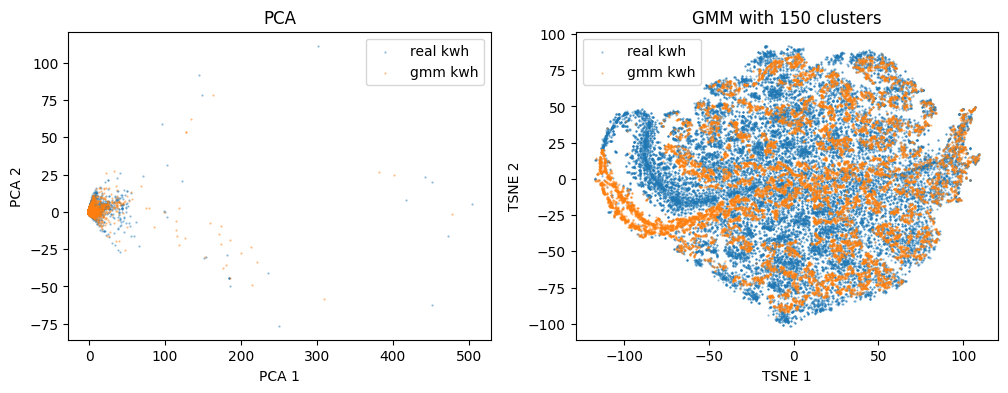

In [38]:
b1, b2, b3, b4 = train_pca_and_tsne(real_kwh, gmm_150)
_ = plot_pca_tsne(b1, b2, b3, b4)
plt.title("GMM with 150 clusters")

Text(0.5, 1.0, 'GMM with 50 clusters')

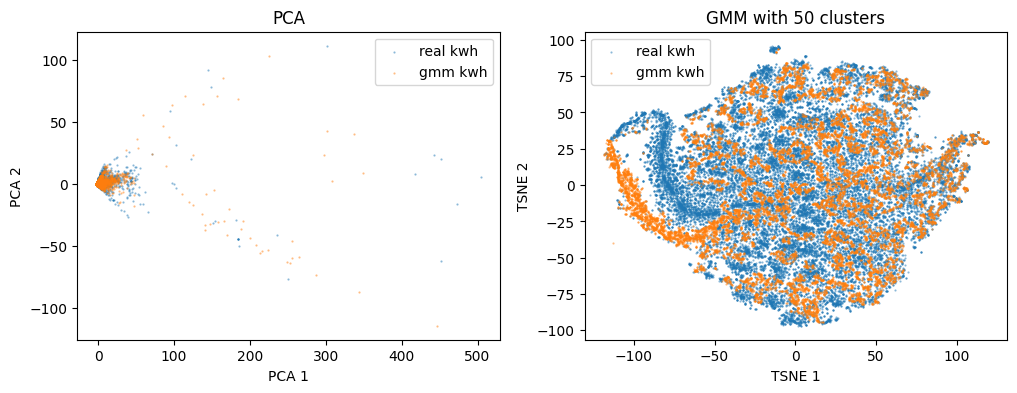

In [39]:
c1, c2, c3, c4 = train_pca_and_tsne(real_kwh, gmm_50)
_ = plot_pca_tsne(c1, c2, c3, c4)
plt.title("GMM with 50 clusters")

Text(0.5, 1.0, 'GMM with 10 clusters')

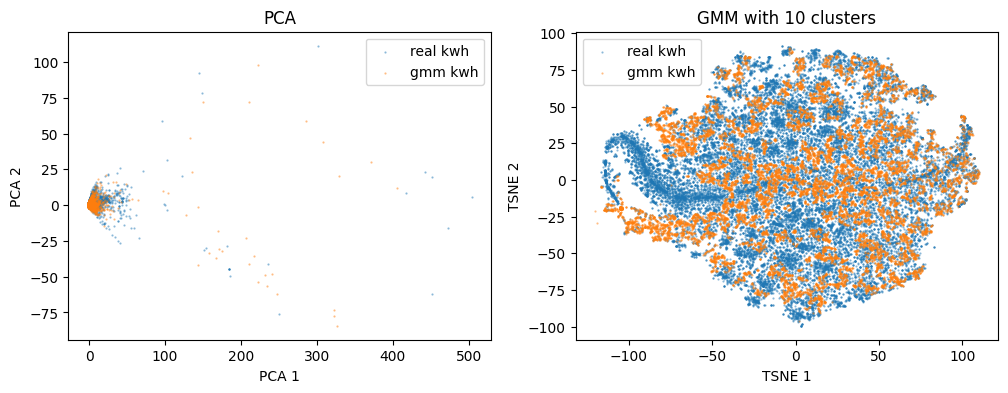

In [40]:
d1, d2, d3, d4 = train_pca_and_tsne(real_kwh, gmm_10)
_ = plot_pca_tsne(d1, d2, d3, d4)
plt.title("GMM with 10 clusters")